# Mechanism-aware drug response prediction - Data preparation & EDA

## Sources

| Layer | Source | File |
|---|---|---|
| Cell line metadata | DepMap 26Q1 | `Model.csv` |
| Expression (RNA-seq) | DepMap 26Q1 | `OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv` |
| Mutations | DepMap 26Q1 | `OmicsSomaticMutationsMAF.maf` |
| CNV | DepMap 26Q1 | `OmicsCNGeneWGS.csv` |
| Methylation (RRBS) | DepMap (legacy 2018) | `CCLE_RRBS_TSS1kb_20181022.txt.gz` |
| Proteomics | Cell Model passports | `Protein_matrix_averaged_20250211.tsv` |
| Drug response (CTRPv2) | PharmacoDB GraphQL API | live query |


## A. DATA PREPARATION

## 1. Setup

In [1]:
# Install packages quietly (idempotent — no-op if already installed)
%pip install -q pandas numpy scipy scikit-learn umap-learn matplotlib seaborn requests pyarrow tqdm upsetplot

  distutils: /private/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/pip-build-env-swv575a3/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/pip-build-env-swv575a3/normal/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  user = False
  home = None
  root = None
  prefix = '/private/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/pip-build-env-swv575a3/normal'
  distutils: /private/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/pip-build-env-swv575a3/overlay/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  distutils: /private/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/pip-build-env-swv575a3/overlay/lib/python3.9/site-packages
  sysconfig: /Library/Python/3.9/site-packages
  user = False
  home = None
  root = None
  prefix = '/private/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/pip-build-env-swv575a3/overlay'
You should 

In [2]:
import os
import re
import json
import gzip
import shutil
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


def clean_gene_id(col: str) -> str:
    """Extract gene symbol from DepMap column names like 'TP53 (7157)'."""
    m = re.match(r"^(\S+)\s*\(", col)
    return m.group(1) if m else col


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

print("Imports OK")

Imports OK


/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/abisolaajuwon/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Paths

In [ ]:
# Project paths
DATA_DIR = Path("./data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed_no_prot_no_methyl"

for d in [RAW_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"RAW_DIR: {RAW_DIR.resolve()}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")


## 2. Download

DepMap 26Q1 files and proteomics are fetched automatically in §2.2 (requires network). Sources:

- DepMap portal: https://depmap.org/portal/data_page/?tab=allData (Release: **DepMap Public 26Q1**)
- Proteomics: Cell Model Passports API → `Proteomics_*.zip` (contains `Protein_matrix_averaged_20250211.tsv`)

```
data/raw/
├── Model.csv                                  (auto)
├── OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv   (auto)
├── OmicsSomaticMutationsMAF.maf                      (auto)
├── OmicsCNGeneWGS.csv                              (auto)
├── Protein_matrix_averaged_20250211.tsv                  (auto)
└── CCLE_RRBS_TSS1kb_20181022.txt.gz (auto, §2.1)
```

### 2.1 Auto-download: legacy methylation RRBS

In [4]:
# DepMap legacy RRBS methylation has a stable URL since 2018
METHYLATION_URL = "https://data.broadinstitute.org/ccle/CCLE_RRBS_TSS1kb_20181022.txt.gz"
methylation_path = RAW_DIR / "CCLE_RRBS_TSS1kb_20181022.txt.gz"

if methylation_path.exists():
    size_mb = methylation_path.stat().st_size / 1024**2
    print(f"Already downloaded: {methylation_path.name} ({size_mb:.1f} MB)")
else:
    try:
        urlretrieve(METHYLATION_URL, methylation_path)
    except Exception as e:
        print(f"  FAILED: {e}")
        print(f"  Download manually from {METHYLATION_URL}")

### 2.2 Auto-download: DepMap 26Q1 + proteomics

In [6]:
from io import BytesIO, StringIO
import zipfile

DEPMAP_RELEASE = "DepMap Public 26Q1"

DEPMAP_FILES = [
    "Model.csv",
    "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv",
    "OmicsSomaticMutationsMAF.maf",
    "OmicsCNGeneWGS.csv",
]

PROTEOMICS_FILE = "Protein_matrix_averaged_20250211.tsv"

DEPMAP_MANIFEST_URL = "https://depmap.org/portal/api/download/files"
CMP_DOWNLOADS_API = "https://api.cellmodelpassports.sanger.ac.uk/download_files?include=groups.files"

MIN_BYTES_BY_FILE = {
    "Model.csv": 100_000,
    "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv": 1_000_000,
    "OmicsSomaticMutationsMAF.maf": 1_000_000,
    "OmicsCNGeneWGS.csv": 1_000_000,
    "Protein_matrix_averaged_20250211.tsv": 1_000_000,
}


def expected_min_bytes(fname: str) -> int:
    return MIN_BYTES_BY_FILE.get(fname, 1_000_000)


def download_file(url: str, dest: Path, desc: str = "") -> None:
    min_bytes = expected_min_bytes(dest.name)

    if dest.exists() and dest.stat().st_size >= min_bytes:
        size_mb = dest.stat().st_size / 1024**2
        print(f"Already downloaded: {dest.name} ({size_mb:.1f} MB)")
        return

    if dest.exists():
        print(f"Removing incomplete/invalid file: {dest.name}")
        dest.unlink()

    print(f"Downloading {desc or dest.name} ...")

    resp = requests.get(
        url,
        stream=True,
        timeout=600,
        headers={"User-Agent": "Mozilla/5.0"},
    )
    resp.raise_for_status()

    total = int(resp.headers.get("content-length", 0))

    with open(dest, "wb") as f, tqdm(
        total=total,
        unit="B",
        unit_scale=True,
        desc=dest.name,
    ) as pbar:
        for chunk in resp.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

    if dest.stat().st_size < min_bytes:
        raise RuntimeError(
            f"{dest.name} download too small "
            f"({dest.stat().st_size} B). Got HTML/error page?"
        )

    size_mb = dest.stat().st_size / 1024**2
    print(f"  Saved: {dest.name} ({size_mb:.1f} MB)")


def download_proteomics_matrix(dest: Path) -> None:
    min_bytes = expected_min_bytes(dest.name)

    if dest.exists() and dest.stat().st_size >= min_bytes:
        size_mb = dest.stat().st_size / 1024**2
        print(f"Already downloaded: {dest.name} ({size_mb:.1f} MB)")
        return

    if dest.exists():
        print(f"Removing incomplete/invalid file: {dest.name}")
        dest.unlink()

    resp = requests.get(
        CMP_DOWNLOADS_API,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/vnd.api+json",
        },
        timeout=60,
    )
    resp.raise_for_status()

    zip_entries = [
        (attrs["timestamp"], url)
        for f in resp.json().get("included", [])
        if f.get("type") == "download_file"
        for attrs in [f.get("attributes") or {}]
        for url in [attrs.get("url") or ""]
        if url.endswith(".zip") and "/Proteomics_" in url
    ]

    if not zip_entries:
        raise RuntimeError("No proteomics zip found in Cell Model Passports API")

    zip_url = sorted(zip_entries, reverse=True)[0][1]

    print("Downloading proteomics bundle ...")

    zip_resp = requests.get(
        zip_url,
        timeout=600,
        headers={"User-Agent": "Mozilla/5.0"},
    )
    zip_resp.raise_for_status()

    with zipfile.ZipFile(BytesIO(zip_resp.content)) as zf:
        if dest.name not in zf.namelist():
            raise RuntimeError(
                f"{dest.name} not found in proteomics zip. "
                f"Available files: {zf.namelist()}"
            )

        dest.write_bytes(zf.read(dest.name))

    if dest.stat().st_size < min_bytes:
        raise RuntimeError(
            f"{dest.name} extracted file too small "
            f"({dest.stat().st_size} B)."
        )

    size_mb = dest.stat().st_size / 1024**2
    print(f"  Extracted: {dest.name} ({size_mb:.1f} MB)")


# Make sure RAW_DIR exists
RAW_DIR.mkdir(parents=True, exist_ok=True)

print(f"RAW_DIR: {RAW_DIR.resolve()}")


# Download DepMap 26Q1 files
manifest_resp = requests.get(
    DEPMAP_MANIFEST_URL,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=120,
)
manifest_resp.raise_for_status()

manifest = pd.read_csv(StringIO(manifest_resp.text))

release_files = manifest[
    manifest["release"] == DEPMAP_RELEASE
].set_index("filename")

for fname in DEPMAP_FILES:
    if fname not in release_files.index:
        print(f"[ERROR] {fname} not found in {DEPMAP_RELEASE} manifest")
        continue

    file_url = release_files.loc[fname, "url"]
    download_file(file_url, RAW_DIR / fname, fname)


# Download proteomics file
download_proteomics_matrix(RAW_DIR / PROTEOMICS_FILE)


# Final status check
all_files = DEPMAP_FILES + [PROTEOMICS_FILE]

present = []
missing = []

for fname in all_files:
    path = RAW_DIR / fname
    min_bytes = expected_min_bytes(fname)

    if path.exists() and path.stat().st_size >= min_bytes:
        size_mb = path.stat().st_size / 1024**2
        present.append(f"[OK] {fname:<60} {size_mb:.1f} MB")
    else:
        missing.append(f"[MISSING/INVALID] {fname}")

print("\nFile status:")
print("\n".join(present))

if missing:
    print("\nStill missing or invalid:")
    print("\n".join(missing))
else:
    print("\nAll required files present.")


    

RAW_DIR: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/data/raw
Already downloaded: Model.csv (0.7 MB)
Already downloaded: OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv (290.9 MB)
Already downloaded: OmicsSomaticMutationsMAF.maf (141.6 MB)
Already downloaded: OmicsCNGeneWGS.csv (390.1 MB)
Already downloaded: Protein_matrix_averaged_20250211.tsv (48.6 MB)

File status:
[OK] Model.csv                                                    0.7 MB
[OK] OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv           290.9 MB
[OK] OmicsSomaticMutationsMAF.maf                                 141.6 MB
[OK] OmicsCNGeneWGS.csv                                           390.1 MB
[OK] Protein_matrix_averaged_20250211.tsv                         48.6 MB

All required files present.


### 2.3 PharmacoDB GraphQL — CTRPv2 drug response

PharmacoDB is an integrative database developed by the Haibe-Kains lab (Toronto) that consolidates 10 major drug screens (CCLE, GDSC1/2, CTRPv2, PRISM, NCI60, FIMM, gCSI, GRAY, UHNBreast). A GraphQL API is available at https://pharmacodb.ca/graphql and requires no authentication.

A specific feature of their schema is that `experiments` cannot be filtered directly by `dataset`—only by `cellLineId`, `compoundId`, or `tissueId`. Therefore, the strategy is as follows:

Use the `datasets` query to retrieve the ID for CTRPv2.
Use the `compounds(all: true)` query to fetch all compounds—along with the datasets to which they belong—and then filter the results to include only those associated with CTRPv2.
For each CTRPv2 compound, execute the query `experiments(compoundId: X, all: true)` and filter the results for CTRPv2 on the client side.
The actual `Experiment` schema is as follows:

```
type Experiment
{
cell_line: CellLineWithTissueDataset
compound:  Compound
dataset:   Dataset
profile:   Profile  # AAC, IC50, EC50, HS, Einf, DSS1, DSS2, DSS3
}
```

In [7]:
# PharmacoDB GraphQL endpoint
PHARMACODB_URL = "https://pharmacodb.ca/graphql"

def gql_query(query: str, variables: dict = None, timeout: int = 120):
    """Execute a GraphQL query against PharmacoDB."""
    payload = {"query": query}
    if variables:
        payload["variables"] = variables
    r = requests.post(
        PHARMACODB_URL,
        json=payload,
        headers={"Content-Type": "application/json"},
        timeout=timeout,
    )
    r.raise_for_status()
    data = r.json()
    if "errors" in data:
        raise RuntimeError(f"GraphQL errors: {data['errors']}")
    return data["data"]


# Step 1: discover datasets and find CTRPv2
DATASETS_QUERY = "query { datasets { id name } }"
ds_info = gql_query(DATASETS_QUERY)
datasets_list = ds_info["datasets"]
print(f"PharmacoDB datasets ({len(datasets_list)}):")
for d in datasets_list:
    print(f"id={d['id']}  name={d['name']}")

PharmacoDB datasets (10):
id=1  name=CCLE
id=2  name=CTRPv2
id=3  name=FIMM
id=4  name=GDSC1
id=5  name=GDSC2
id=6  name=GRAY
id=7  name=NCI60
id=8  name=PRISM
id=9  name=UHNBreast
id=10  name=gCSI


In [8]:
CTRPV2_ID = 2
CTRPV2_NAME = 'CTRPv2'

We download all PharmacoDB compounds in a single request—each entry contains a `datasets` array, which we use for filtering.

In [9]:
# Step 2: get all compounds + their dataset memberships, filter to CTRPv2
COMPOUNDS_QUERY = """
query {
  compounds(all: true) {
    id
    name
    uid
    datasets { id name }
    annotation { smiles inchikey pubchem fda_status chembl }
  }
}
"""

compounds_path = RAW_DIR / "ctrpv2_compounds.parquet"

if compounds_path.exists():
    df_comp = pd.read_parquet(compounds_path)
    print(f"Loaded cached: {compounds_path.name}  ({len(df_comp)} compounds)")
else:
    comp_data = gql_query(COMPOUNDS_QUERY)
    all_comps = comp_data["compounds"]
    print(f"total compounds in PharmacoDB: {len(all_comps)}")

    # Filter to CTRPv2 members
    ctrpv2_comps = [c for c in all_comps if any(d["id"] == CTRPV2_ID for d in (c.get("datasets") or []))]
    print(f"CTRPv2 compounds: {len(ctrpv2_comps)}")

    records = []
    for c in ctrpv2_comps:
        ann = c.get("annotation") or {}
        records.append({
            "compound_id": c["id"],
            "compound": c["name"],
            "uid": c.get("uid"),
            "smiles": ann.get("smiles"),
            "inchikey": ann.get("inchikey"),
            "pubchem_cid": ann.get("pubchem"),
            "fda_status": ann.get("fda_status"),
            "chembl_id": ann.get("chembl"),
        })
    df_comp = pd.DataFrame(records)
    df_comp.to_parquet(compounds_path, index=False)
    print(f"\nSaved: {compounds_path.name}")
    df_comp.head(3)

total compounds in PharmacoDB: 56149
CTRPv2 compounds: 544

Saved: ctrpv2_compounds.parquet


For each CTRPv2 compound, we query its associated experiments. The call `experiments(compoundId: X, all: true)` returns all experiments for that compound across all datasets; we then filter for CTRPv2 on the client side.

In [10]:
# Step 3: pull experiments for each CTRPv2 compound
EXPERIMENTS_QUERY = """
query Exp($compoundId: Int!) {
  experiments(compoundId: $compoundId, all: true) {
    cell_line { name uid }
    compound { name uid }
    dataset { id name }
    profile { AAC IC50 EC50 HS Einf }
  }
}
"""

ctrpv2_path = RAW_DIR / "ctrpv2_experiments.parquet"

if ctrpv2_path.exists():
    print(f"Already downloaded: {ctrpv2_path.name}")
    df_ctrp = pd.read_parquet(ctrpv2_path)
    print(f"records: {len(df_ctrp):,}")
else:
    all_records = []
    failed = []
    for _, row in tqdm(df_comp.iterrows(), total=len(df_comp), desc="Compounds"):
        cid = int(row["compound_id"])
        cname = row["compound"]
        try:
            data = gql_query(EXPERIMENTS_QUERY, variables={"compoundId": cid})
            exps = data.get("experiments") or []
            for e in exps:
                # Filter to CTRPv2 only (compound may have been tested in other datasets too)
                ds = e.get("dataset") or {}
                if ds.get("id") != CTRPV2_ID:
                    continue
                cl = e.get("cell_line") or {}
                prof = e.get("profile") or {}
                all_records.append({
                    "cell_line": cl.get("name"),
                    "cell_line_uid": cl.get("uid"),
                    "compound": cname,
                    "compound_id": cid,
                    "AAC": prof.get("AAC"),
                    "IC50": prof.get("IC50"),
                    "EC50": prof.get("EC50"),
                    "HS": prof.get("HS"),
                    "Einf": prof.get("Einf"),
                })
        except Exception as e:
            failed.append((cname, str(e)))

    df_ctrp = pd.DataFrame(all_records)
    df_ctrp.to_parquet(ctrpv2_path, index=False)
    print(f"\nSaved: {ctrpv2_path.name}")
    if failed:
        print(f"failed compounds: {len(failed)}  (first 5: {failed[:5]})")

Compounds: 100%|██████████| 544/544 [06:54<00:00,  1.31it/s]



Saved: ctrpv2_experiments.parquet


In [11]:
print(f"CTRPv2 drug response from PharmacoDB:")
print(f"records: {len(df_ctrp):>8,}")
print(f"unique cells: {df_ctrp['cell_line'].nunique():>8,}")
print(f"unique drugs: {df_ctrp['compound'].nunique():>8,}")
print(f"\nAAC stats:")
print(df_ctrp["AAC"].describe())
print(f"\nIC50 stats:")
print(df_ctrp["IC50"].describe())

CTRPv2 drug response from PharmacoDB:
records:  395,263
unique cells:      887
unique drugs:      544

AAC stats:
count    371066.000000
mean          0.153236
std           0.166478
min           0.000000
25%           0.027901
50%           0.100051
75%           0.224633
max           0.995290
Name: AAC, dtype: float64

IC50 stats:
count    2.452480e+05
mean     3.680614e+50
std      1.915902e+52
min      1.000000e-06
25%      2.185067e+00
50%      1.201679e+01
75%      5.055414e+01
max      1.000000e+54
Name: IC50, dtype: float64


## 3. Loading raw data

### 3.1 Cell line metadata

In [12]:
model = pd.read_csv(RAW_DIR / "Model.csv")
print(f"Model.csv: {model.shape}")
print(f"\nColumns ({len(model.columns)}):")
print(list(model.columns))
model.head(3)

Model.csv: (2154, 49)

Columns (49):
['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures', 'RRID', 'Age', 'AgeCategory', 'Sex', 'PatientRace', 'PrimaryOrMetastasis', 'SampleCollectionSite', 'SourceType', 'SourceDetail', 'CatalogNumber', 'ModelType', 'TissueOrigin', 'ModelDerivationMaterial', 'ModelTreatment', 'PatientTreatmentStatus', 'PatientTreatmentType', 'PatientTreatmentDetails', 'Stage', 'StagingSystem', 'PatientTumorGrade', 'PatientTreatmentResponse', 'GrowthPattern', 'OnboardedMedia', 'FormulationID', 'SerumFreeMedia', 'PlateCoating', 'EngineeredModel', 'EngineeredModelDetails', 'CulturedResistanceDrug', 'PublicComments', 'CCLEName', 'HCMIID', 'PediatricModelType', 'ModelAvailableInDbgap', 'ModelSubtypeFeatures', 'WTSIMasterCellID', 'SangerModelID', 'COSMICID', 'ModelIDAlias']


,ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,PatientSubtypeFeatures,RRID,Age,AgeCategory,Sex,PatientRace,PrimaryOrMetastasis,SampleCollectionSite,SourceType,SourceDetail,CatalogNumber,ModelType,TissueOrigin,ModelDerivationMaterial,ModelTreatment,PatientTreatmentStatus,PatientTreatmentType,PatientTreatmentDetails,Stage,StagingSystem,PatientTumorGrade,PatientTreatmentResponse,GrowthPattern,OnboardedMedia,FormulationID,SerumFreeMedia,PlateCoating,EngineeredModel,EngineeredModelDetails,CulturedResistanceDrug,PublicComments,CCLEName,HCMIID,PediatricModelType,ModelAvailableInDbgap,ModelSubtypeFeatures,WTSIMasterCellID,SangerModelID,COSMICID,ModelIDAlias
0,ACH-000001,PT-gj46wT,NIH:OVCAR-3,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,HGSOC,NaN,CVCL_0465,60.0,Adult,Female,caucasian,Metastatic,ascites,ATCC,NaN,HTB-161,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-001-041,RPMI + 20% FBS + 0.01 mg/ml insulin,False,NaN,NaN,NaN,NaN,NaN,NIHOVCAR3_OVARY,NaN,False,Approved for public sharing - CCLE,NaN,2201.0,SIDM00105,905933.0,NaN
1,ACH-000002,PT-5qa3uk,HL-60,HL60,AMLMRC,Myeloid,Acute Myeloid Leukemia,AML with Myelodysplasia-Related Changes,AMLMRC,"TP53(del), CDKN2A and NRAS mutations [PubMed=2...",CVCL_0002,36.0,Adult,Female,caucasian,Primary,haematopoietic_and_lymphoid_tissue,ATCC,NaN,CCL-240,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Suspension,MF-005-001,IMDM + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,True,Approved for public sharing - CCLE,"NRAS, BCOR and CDKN2A",55.0,SIDM00829,905938.0,NaN
2,ACH-000003,PT-puKIyc,CACO2,CACO2,COAD,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,COAD,NaN,CVCL_0025,72.0,Adult,Male,caucasian,Primary,Colon,ATCC,NaN,HTB-37,Cell Line,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-015-009,EMEM + 20% FBS,False,NaN,NaN,NaN,NaN,NaN,CACO2_LARGE_INTESTINE,NaN,False,Approved for public sharing - CCLE,NaN,NaN,SIDM00891,NaN,NaN


In [13]:
# Key metadata columns we will use downstream
key_meta_cols = [
    "ModelID", "StrippedCellLineName", "CCLEName", "OncotreeLineage",
    "OncotreePrimaryDisease", "OncotreeSubtype", "PrimaryOrMetastasis", "Sex", "Age"
]
present_cols = [c for c in key_meta_cols if c in model.columns]
print(f"Available key columns: {present_cols}")
model_meta = model[present_cols].copy()
print(f"\nTotal cell lines: {len(model_meta)}")
print(f"\nLineage distribution (top 15):")
print(model_meta["OncotreeLineage"].value_counts().head(15))

Available key columns: ['ModelID', 'StrippedCellLineName', 'CCLEName', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'PrimaryOrMetastasis', 'Sex', 'Age']

Total cell lines: 2154

Lineage distribution (top 15):
OncotreeLineage
Lymphoid                     266
Lung                         261
Skin                         150
CNS/Brain                    127
Esophagus/Stomach            104
Bone                         101
Soft Tissue                   99
Bowel                         99
Breast                        96
Head and Neck                 94
Myeloid                       88
Ovary/Fallopian Tube          76
Kidney                        74
Pancreas                      68
Peripheral Nervous System     62
Name: count, dtype: int64


### 3.2 Expression (RNA-seq, log2(TPM+1))

In [14]:
import re

def clean_gene_id(col: str) -> str:
    """Extract gene symbol from DepMap column names like 'TP53 (7157)'."""
    m = re.match(r"^(\S+)\s*\(", col)
    return m.group(1) if m else col

expr_full = pd.read_csv(
    RAW_DIR / "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv",
)
expr_full = expr_full[expr_full["IsDefaultEntryForModel"] == "Yes"]
expr = expr_full.set_index("ModelID")
expr = expr.select_dtypes(include=[np.number])
expr.columns = [clean_gene_id(c) for c in expr.columns]
expr = expr.loc[:, ~expr.columns.duplicated()]
print(f"Expression: {expr.shape}, unique gene symbols: {expr.columns.nunique()}")

Expression: (1719, 19216), unique gene symbols: 19216


In [15]:
expr.head(10)

,Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,LAS1L,ENPP4,SEMA3F,CFTR,ANKIB1,CYP51A1,KRIT1,RAD52,MYH16,BAD,LAP3,CD99,...,ASDURF,SMIM10L3,SPEGNB,FAM246A,TMEM217B,NOTCH2NLR,SPADH,SPDYE14,DERPC,FAM246B,NOTCH2NLC,H3C2,SMIM40,H3C3,CIMIP3,ATXN8,SMIM42,NPBWR1,ACTL10,RNF228,PANO1,HRURF,PRRC2B,F8A2,F8A1
ModelID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACH-001113,0,4.956577,0.000000,7.577648,3.179411,4.765742,0.037483,1.510547,3.103039,6.697482,4.852303,3.497101,4.253384,5.039358,2.873880,3.226268,0.000000,5.347148,6.964630,5.641245,3.706387,0.076894,5.585888,4.856592,5.698257,...,4.334225,0.0,0.291473,0.0,0.000000,2.713144,0.0,0.000000,4.395214,0.0,3.427618,2.763120,0.000000,0.093516,0.0,0.0,0.0,0.414727,0.077634,1.113094,0.411901,0.0,5.134808,1.214541,4.315653
ACH-001289,1,4.955015,0.617117,7.333933,2.782935,3.735371,0.000000,0.148922,3.855123,4.376707,3.465922,1.977529,3.223240,4.790318,4.280221,1.461932,0.029911,5.339879,7.363749,5.034238,2.834440,0.000000,6.156269,6.250412,6.424030,...,3.706287,0.0,0.000000,0.0,0.000000,0.066458,0.0,0.000000,4.055838,0.0,6.240925,1.320074,0.120649,0.671615,0.0,0.0,0.0,0.029809,0.000000,1.269267,1.026807,0.0,5.953793,0.006969,4.250636
ACH-001339,2,3.421952,0.000000,7.546069,2.615880,4.476233,0.064571,1.397491,6.833915,3.980336,3.437155,3.078680,3.620422,4.155158,1.102793,0.262396,0.064436,4.340797,5.904043,4.955987,2.506747,0.003578,5.096717,6.269128,8.173098,...,2.108692,0.0,0.000000,0.0,0.000000,3.064350,0.0,0.002613,3.828439,0.0,4.292436,0.627906,0.867237,0.689369,0.0,0.0,0.0,0.127768,0.105594,0.413829,0.540575,0.0,4.205971,0.030894,2.783448
ACH-001979,4,4.651643,0.000000,5.946408,2.454515,1.852111,0.000000,7.680796,6.156866,5.042574,3.258451,3.194224,5.207666,4.629963,0.000000,0.419227,0.462704,4.418244,6.438015,5.069053,1.848410,0.128745,5.053415,7.138825,8.142944,...,2.924227,0.0,0.191630,0.0,0.316207,2.722414,0.0,0.000000,4.738422,0.0,2.964386,0.000000,0.338836,0.000000,0.0,0.0,0.0,0.012012,0.000000,1.006470,0.729221,0.0,4.922916,0.150926,4.661556
ACH-002438,5,4.336705,0.000000,6.879387,2.262824,3.256491,0.000000,2.253926,6.895436,3.470992,4.308375,2.629144,3.850699,4.191365,2.308501,5.127972,0.000000,4.588780,5.873437,4.424351,2.691789,0.054747,5.738401,5.989098,8.960674,...,2.227735,0.0,0.750876,0.0,0.000000,2.031794,0.0,0.000000,4.147062,0.0,3.458790,0.255362,0.000000,0.278721,0.0,0.0,0.0,0.024008,0.984538,3.003708,0.549131,0.0,4.949465,0.000000,6.202939
ACH-001538,6,5.599937,0.000000,7.454151,2.936042,3.449483,0.000000,6.351800,6.272593,4.865335,4.017788,2.457597,4.541397,5.677009,4.134147,3.179024,0.026946,4.138675,6.503027,3.893382,2.541782,0.937902,5.677751,5.363052,6.773020,...,1.259592,0.0,0.000000,0.0,0.000000,0.705958,0.0,0.000000,3.175125,0.0,1.523783,0.232709,0.000000,0.315411,0.0,0.0,0.0,0.031495,1.576542,0.000000,0.188157,0.0,4.923192,2.284002,4.995136
ACH-000242,7,7.105940,0.000000,6.677480,2.700054,4.122184,0.819019,7.696981,5.757754,7.584038,4.620352,2.010952,2.675642,5.143324,1.318542,5.840431,0.047223,4.569479,7.161716,5.170286,3.147041,0.027180,5.803904,5.662610,6.843682,...,1.721753,0.0,0.205066,0.0,0.000000,2.306598,0.0,0.000000,2.284766,0.0,2.238610,0.978907,0.000000,1.887915,0.0,0.0,0.0,0.440622,0.989241,0.056678,0.372141,0.0,5.672335,0.000000,4.702203
ACH-000708,8,4.618039,0.135636,7.163468,2.669519,4.017842,0.000000,0.148095,5.014815,5.331662,3.441397,2.559541,3.716124,4.949773,3.297599,2.133386,6.681042,3.907006,6.561803,4.852828,2.649818,0.006687,4.524201,5.218130,7.060102,...,1.133327,0.0,0.375405,0.0,0.000000,0.520757,0.0,0.000000,2.973047,0.0,1.462544,1.167396,0.000000,1.119091,0.0,0.0,0.0,0.000000,2.859898,0.009637,0.828799,0.0,5.129225,1.952054,3.294400
ACH-000327,9,3.759710,0.000000,6.062055,1.931978,2.801039,0.008343,3.155547,6.022998,3.989239,2.674431,1.458933,3.646854,3.840493,3.807417,0.493686,0.737432,3.417641,6.447981,4.422267,2.773399,0.077134,4.354904,5.599806,4.769200,...,0.769006,0.0,0.252303,0.0,0.000000,0

DepMap codes genes as `SYMBOL (EntrezID)`. Retreiver symbols 

In [16]:
# Example cleaned column names (was "SYMBOL (EntrezID)")
list(expr.columns[:8])

['Unnamed: 0', 'TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM', 'FGR', 'CFH']

In [17]:
expr.head()

,Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,LAS1L,ENPP4,SEMA3F,CFTR,ANKIB1,CYP51A1,KRIT1,RAD52,MYH16,BAD,LAP3,CD99,...,ASDURF,SMIM10L3,SPEGNB,FAM246A,TMEM217B,NOTCH2NLR,SPADH,SPDYE14,DERPC,FAM246B,NOTCH2NLC,H3C2,SMIM40,H3C3,CIMIP3,ATXN8,SMIM42,NPBWR1,ACTL10,RNF228,PANO1,HRURF,PRRC2B,F8A2,F8A1
ModelID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACH-001113,0,4.956577,0.000000,7.577648,3.179411,4.765742,0.037483,1.510547,3.103039,6.697482,4.852303,3.497101,4.253384,5.039358,2.873880,3.226268,0.000000,5.347148,6.964630,5.641245,3.706387,0.076894,5.585888,4.856592,5.698257,...,4.334225,0.0,0.291473,0.0,0.000000,2.713144,0.0,0.000000,4.395214,0.0,3.427618,2.763120,0.000000,0.093516,0.0,0.0,0.0,0.414727,0.077634,1.113094,0.411901,0.0,5.134808,1.214541,4.315653
ACH-001289,1,4.955015,0.617117,7.333933,2.782935,3.735371,0.000000,0.148922,3.855123,4.376707,3.465922,1.977529,3.223240,4.790318,4.280221,1.461932,0.029911,5.339879,7.363749,5.034238,2.834440,0.000000,6.156269,6.250412,6.424030,...,3.706287,0.0,0.000000,0.0,0.000000,0.066458,0.0,0.000000,4.055838,0.0,6.240925,1.320074,0.120649,0.671615,0.0,0.0,0.0,0.029809,0.000000,1.269267,1.026807,0.0,5.953793,0.006969,4.250636
ACH-001339,2,3.421952,0.000000,7.546069,2.615880,4.476233,0.064571,1.397491,6.833915,3.980336,3.437155,3.078680,3.620422,4.155158,1.102793,0.262396,0.064436,4.340797,5.904043,4.955987,2.506747,0.003578,5.096717,6.269128,8.173098,...,2.108692,0.0,0.000000,0.0,0.000000,3.064350,0.0,0.002613,3.828439,0.0,4.292436,0.627906,0.867237,0.689369,0.0,0.0,0.0,0.127768,0.105594,0.413829,0.540575,0.0,4.205971,0.030894,2.783448
ACH-001979,4,4.651643,0.000000,5.946408,2.454515,1.852111,0.000000,7.680796,6.156866,5.042574,3.258451,3.194224,5.207666,4.629963,0.000000,0.419227,0.462704,4.418244,6.438015,5.069053,1.848410,0.128745,5.053415,7.138825,8.142944,...,2.924227,0.0,0.191630,0.0,0.316207,2.722414,0.0,0.000000,4.738422,0.0,2.964386,0.000000,0.338836,0.000000,0.0,0.0,0.0,0.012012,0.000000,1.006470,0.729221,0.0,4.922916,0.150926,4.661556
ACH-002438,5,4.336705,0.000000,6.879387,2.262824,3.256491,0.000000,2.253926,6.895436,3.470992,4.308375,2.629144,3.850699,4.191365,2.308501,5.127972,0.000000,4.588780,5.873437,4.424351,2.691789,0.054747,5.738401,5.989098,8.960674,...,2.227735,0.0,0.750876,0.0,0.000000,2.031794,0.0,0.000000,4.147062,0.0,3.458790,0.255362,0.000000,0.278721,0.0,0.0,0.0,0.024008,0.984538,3.003708,0.549131,0.0,4.949465,0.000000,6.202939


### 3.3 Mutations

In [18]:
mut = pd.read_csv(
    RAW_DIR / "OmicsSomaticMutationsMAF.maf",
    sep="\t",          # MAF is tab-separated
    comment="#",       # skip header lines like "#version 2.4"
    low_memory=False,  # MAF has many columns, mixed types
)
print(mut.shape)
print(mut.columns.tolist()[:20])

(1172688, 18)
['Chromosome', 'Start_Position', 'End_Position', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'DepMap_ID', 'Variant_Classification', 'Protein_Change', 'Hugo_Symbol', 'NCBI_Build', 'Strand', 'InFrame', 'ModelConditionID', 'IsDefaultEntryForMC', 'ModelID', 'IsDefaultEntryForModel']


In [19]:
mut.head()

,Chromosome,Start_Position,End_Position,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,DepMap_ID,Variant_Classification,Protein_Change,Hugo_Symbol,NCBI_Build,Strand,InFrame,ModelConditionID,IsDefaultEntryForMC,ModelID,IsDefaultEntryForModel
0,chr1,818203,818203,SNP,G,G,A,CDS-aN8PNg,Splice_Site,NaN,FAM87B,GRCh38,+,False,MC-000062-eiDD,Yes,ACH-000062,Yes
1,chr1,918916,918919,DEL,CTGA,CTGA,C,CDS-qjpRtt,Splice_Site,NaN,LINC02593,GRCh38,+,True,MC-002059-DNM1,Yes,ACH-002059,Yes
2,chr1,924510,924511,DNP,GC,GC,AA,CDS-bOBkBi,Missense_Mutation,p.A27K,SAMD11,GRCh38,+,False,MC-000402-iC8K,Yes,ACH-000402,Yes
3,chr1,924657,924657,SNP,C,C,G,CDS-52aoJ0,Missense_Mutation,p.L76V,SAMD11,GRCh38,+,False,MC-000693-vUEr,Yes,ACH-000693,Yes
4,chr1,924750,924750,SNP,C,C,T,CDS-jBuyoZ,Missense_Mutation,p.P107S,SAMD11,GRCh38,+,False,MC-000930-v0gO,Yes,ACH-000930,Yes


Mutations in DepMap are distributed in long format (one row = one mutation in a cell line). For ML, we require a wide cell × gene matrix containing a binary flag (presence/absence of a non-silent mutation).

In [20]:
GENE_COL = "Hugo_Symbol"
MODEL_COL = "ModelID"
EFFECT_COL = "Variant_Classification"

print(f"Using: gene={GENE_COL}, model={MODEL_COL}, effect={EFFECT_COL}")
print(f"\nUnique cell lines with mutations: {mut[MODEL_COL].nunique()}")
print(f"Unique genes mutated: {mut[GENE_COL].nunique()}")
print(f"\n{EFFECT_COL} distribution:")
print(mut[EFFECT_COL].value_counts().head(15))

Using: gene=Hugo_Symbol, model=ModelID, effect=Variant_Classification

Unique cell lines with mutations: 1968
Unique genes mutated: 20147

Variant_Classification distribution:
Variant_Classification
Missense_Mutation         965354
Frame_Shift_Del            67539
Nonsense_Mutation          63889
Splice_Site                37142
Frame_Shift_Ins            24638
In_Frame_Del                7283
In_Frame_Ins                2527
Translation_Start_Site      2287
Nonstop_Mutation            1500
5'Flank                      440
Splice_Region                 57
5'UTR                         13
Intron                        10
RNA                            6
3'Flank                        3
Name: count, dtype: int64


### 3.4 Copy Number (CNV)

In [21]:
cnv = pd.read_csv(
    RAW_DIR / "OmicsCNGeneWGS.csv",
    index_col="ModelID",
)
# Drop metadata columns (SequencingID, ModelConditionID, IsDefaultEntryFor*)
cnv = cnv.select_dtypes(include=[np.number])
print(f"CNV shape: {cnv.shape}")
print(f"Index sample: {cnv.index[:3].tolist()}")

CNV shape: (1132, 19956)
Index sample: ['ACH-000839', 'ACH-000041', 'ACH-002046']


In [22]:
# Clean column names same way as expression
cnv.columns = [clean_gene_id(c) for c in cnv.columns]
cnv = cnv.loc[:, ~cnv.columns.duplicated()]
print(f"After cleaning: {cnv.shape}")

After cleaning: (1132, 19956)


In [23]:
cnv.head()

,Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,LAS1L,ENPP4,SEMA3F,CFTR,ANKIB1,CYP51A1,KRIT1,RAD52,BAD,LAP3,CD99,ENSG00000002586_PAR_Y,...,ENSG00000288671,ENSG00000288674,PANO1,HRURF,ENSG00000288678,ENSG00000288681,ENSG00000288683,ENSG00000288684,ENSG00000288695,ENSG00000288698,ENSG00000288699,PRRC2B,UGT1A3,UGT1A5,ENSG00000288706,ENSG00000288708,F8A2,ENSG00000288710,ENSG00000288711,ENSG00000288712,ENSG00000288715,ENSG00000288716,ENSG00000288721,F8A1,ENSG00000288725
ModelID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACH-000839,0,0.721540,0.715798,1.468716,1.337217,1.331376,1.055111,1.417554,1.079890,1.077240,1.083957,1.112442,1.110515,0.408926,1.051498,0.716682,0.990871,1.042192,1.024632,1.031381,1.223920,1.444480,0.765494,NaN,NaN,...,1.205352,1.495151,1.088537,0.852085,NaN,1.054964,1.122053,1.018804,0.864888,1.180124,1.004497,1.047194,1.033189,1.033761,0.352643,0.939455,NaN,1.086583,0.726846,0.630995,1.178647,0.577969,1.012723,NaN,1.262451
ACH-000041,1,0.704745,0.704060,1.420700,1.277700,1.257585,1.277932,1.242876,0.970139,1.003815,1.088711,1.301477,1.319544,0.707109,1.033454,0.854004,1.033618,1.053368,1.082266,1.042960,1.300227,1.315251,0.903586,NaN,NaN,...,0.760496,1.238803,1.416652,1.408686,NaN,1.091751,0.728978,1.004856,0.901595,0.875224,0.912753,1.001832,1.025692,1.026452,0.666888,1.146599,NaN,1.427756,1.315415,0.813237,1.008845,0.779556,1.039722,NaN,1.000236
ACH-002046,2,0.693517,0.676029,1.811640,0.882544,0.877152,0.916579,0.840340,1.310412,1.297268,1.292280,0.896952,0.908196,0.731321,1.251449,1.069719,1.241314,1.313635,1.343822,1.334155,0.965773,1.071165,0.667384,NaN,NaN,...,0.971822,0.895455,1.119874,1.244711,NaN,1.007326,0.773693,1.172950,0.729329,0.972734,1.146042,1.591300,0.819488,0.805257,0.809804,1.734295,NaN,1.026922,1.017381,0.923557,1.011538,1.157960,1.349353,NaN,1.014535
ACH-002048,3,0.943467,0.887782,0.922087,1.357371,1.280471,0.483819,1.264723,0.837353,1.372026,1.421720,1.373114,1.372096,0.467316,1.284649,0.943458,1.716769,1.867048,1.868819,1.919623,1.310175,2.256896,0.843814,NaN,NaN,...,1.359020,0.951467,1.026520,0.937040,NaN,1.029856,0.930126,0.856174,0.854525,1.308518,0.862871,0.951295,1.115616,1.130426,1.021840,1.163138,NaN,1.414714,0.900836,0.842420,0.568750,0.786896,1.403736,NaN,0.906570
ACH-000042,4,1.116780,1.112262,1.270872,1.248270,1.218616,0.885334,1.197612,0.579956,0.641042,0.646325,0.900391,0.888312,1.067438,0.705960,0.607576,0.989458,0.982805,0.989165,0.966969,1.094002,1.178981,1.171190,NaN,NaN,...,0.970398,1.163072,0.604109,0.590481,NaN,0.841140,1.810427,0.613357,0.895255,1.298658,0.616285,1.169577,1.074885,1.069914,0.707920,0.705763,NaN,0.880028,0.935159,0.484517,1.087632,0.422865,0.640969,NaN,1.089239


### 3.5 Methylation 

`CCLE_RRBS_TSS1kb_20181022.txt.gz` — legacy CCLE methylation data from 2018, still the canonical source. RRBS measures DNA methylation as beta-values ∈ [0, 1] per CpG; this file aggregates them over ±1 kb windows around each transcription start site, giving one value per promoter (~21,000 rows). Columns are ~840 cell lines plus 3 metadata columns (`locus_id`, `CpG_sites_hg19`, `avg_coverage`) — note that rows and columns are transposed relative to other omics layers. Cell line names use the **legacy CCLE format** (`HCT116_LARGE_INTESTINE`) rather than `ModelID`, so we translate them via `Model.csv` using the `to_model_id` function; unresolvable names are dropped.

In [25]:
# RRBS file is gzipped tab-separated, with metadata in first columns
meth_raw = pd.read_csv(
    RAW_DIR / "CCLE_RRBS_TSS1kb_20181022.txt.gz",
    sep="\t",
    compression="gzip",
)
print(f"Methylation raw shape: {meth_raw.shape}")
print(f"\nFirst 5 columns (metadata):")
print(list(meth_raw.columns[:5]))
print(f"\nFirst 3 cell line columns:")
print(list(meth_raw.columns[5:8]))
meth_raw.iloc[:3, :7]

Methylation raw shape: (21338, 846)

First 5 columns (metadata):
['locus_id', 'CpG_sites_hg19', 'avg_coverage', 'DMS53_LUNG', 'SW1116_LARGE_INTESTINE']

First 3 cell line columns:
['P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'UMUC3_URINARY_TRACT']


/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/ipykernel_88759/1893531632.py:2: DtypeWarning: Columns (2,618) have mixed types. Specify dtype option on import or set low_memory=False.
  meth_raw = pd.read_csv(


,locus_id,CpG_sites_hg19,avg_coverage,DMS53_LUNG,SW1116_LARGE_INTESTINE,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
0,SGIP1_1_66998638_66999638,1:66998970;1:66998973;1:66998993;1:66999404;1:...,25.0,0.00000,0.00000,0.75000,0.00000
1,SGIP1_1_66998251_66999251,1:66998970;1:66998973;1:66998993,8.27,0.00000,NaN,NaN,0.00000
2,AZIN2_1_33545713_33546713,1:33546151;1:33546209;1:33546210;1:33546385;1:...,326.58,0.00729,0.03232,0.33160,0.22042


### 3.6 Proteomics 

In [26]:
# Read the raw TSV
prot_raw = pd.read_csv(
    RAW_DIR / "Protein_matrix_averaged_20250211.tsv",
    sep="\t",
    index_col=0,
)
print(f"Raw shape: {prot_raw.shape}")
print(f"\nMetadata-column 'Unnamed: 1' sample values:")
print(prot_raw["Unnamed: 1"].head(8).to_dict())
print(f"\n'symbol' row sample values (UniProt → gene name):")
print(prot_raw.loc["symbol"].head(8).to_dict())

Raw shape: (950, 8454)

Metadata-column 'Unnamed: 1' sample values:
{'symbol': nan, 'model_name': 'model_id', '22RV1': 'SIDM00499', '23132-87': 'SIDM00980', '42-MG-BA': 'SIDM00982', '451Lu': 'SIDM01240', '5637': 'SIDM00807', '639-V': 'SIDM00999'}

'symbol' row sample values (UniProt → gene name):
{'Unnamed: 1': nan, 'A0A075B6K4': 'IGLV3-10', 'A0A075B6N1': 'TRBV19', 'A0A075B7B8': 'IGHV3OR16-12', 'A0A075B7D8': 'IGHV3OR15-7', 'A0A087X0M5': 'TRBV18', 'A0A0B4J1V0': 'IGHV3-15', 'A0A0B4J2F0': 'PIGBOS1'}


/var/folders/gk/k7gwn0md6_7brpw16rw8stcc0000gn/T/ipykernel_88759/1247339856.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,2

In [27]:
# Extract UniProt -> gene symbol mapping for proteins (from 'symbol' row)
uniprot_to_gene = prot_raw.loc["symbol"].to_dict()

# Extract cell_line_name -> Sanger SIDM mapping (from 'Unnamed: 1' column)
# Drop metadata rows first so we only get real cell lines
data_rows = prot_raw.drop(index=["symbol", "model_name"], errors="ignore")
cell_to_sanger = data_rows["Unnamed: 1"].to_dict()  # {'22RV1': 'SIDM00xxx', ...}

# Strip metadata: drop the 2 header rows and 1 metadata column
prot = data_rows.drop(columns=[c for c in data_rows.columns if c.startswith("Unnamed")])

# Force numeric conversion (mixed-type column from header rows may have made values strings)
prot = prot.apply(pd.to_numeric, errors="coerce")

print(f"\nClean data shape: {prot.shape}  (cells × proteins)")
print(f"Value range: [{np.nanmin(prot.values):.3f}, {np.nanmax(prot.values):.3f}]")
print(f"Missing fraction: {prot.isna().mean().mean():.1%}")


Clean data shape: (948, 8453)  (cells × proteins)
Value range: [-5.445, 15.653]
Missing fraction: 38.6%


Functions for names harmonization

In [28]:
import re

def build_alias_map(model_df):
    alias_map = {}
    name_cols = [c for c in [
        "StrippedCellLineName", "CCLEName", "CellLineName",
        "ModelID", "SangerModelID", "RRID",
    ] if c in model_df.columns]
    for _, row in model_df.iterrows():
        mid = row["ModelID"]
        for col in name_cols:
            val = row[col]
            if pd.notna(val) and isinstance(val, str):
                alias_map[val.upper()] = mid
                stripped = re.sub(r"[^A-Z0-9]", "", val.upper())
                alias_map[stripped] = mid
    return alias_map

def to_model_id(name, alias_map):
    if not isinstance(name, str):
        return None
    if name.upper() in alias_map:
        return alias_map[name.upper()]
    stripped = re.sub(r"[^A-Z0-9]", "", name.upper())
    return alias_map.get(stripped)

alias_map = build_alias_map(model)
print(f"Alias map built: {len(alias_map):,} entries")

Alias map built: 17,319 entries


In [29]:
# Path 1: try via Sanger SIDM IDs (most authoritative if available)
sanger_to_model = dict(zip(model["SangerModelID"].dropna(), model["ModelID"]))

# Path 2: fallback via cell line name aliases
mapped_index = []
for cell_name in prot.index:
    sidm = cell_to_sanger.get(cell_name)
    mid = sanger_to_model.get(sidm) if sidm else None
    if mid is None:
        # Fallback to name-based mapping via alias_map 
        mid = to_model_id(cell_name, alias_map)
    mapped_index.append(mid)

prot.index = mapped_index
n_before = len(prot)
prot = prot[prot.index.notna()]
prot = prot[~prot.index.duplicated(keep="first")]
print(f"\nMapped to DepMap ModelID: {n_before} → {len(prot)} cell lines")


Mapped to DepMap ModelID: 948 → 947 cell lines


In [30]:
# Optional: rename protein columns from UniProt accession to gene symbol
prot.columns = [uniprot_to_gene.get(c, c) for c in prot.columns]
# Drop columns where mapping failed or duplicated
prot = prot.loc[:, ~prot.columns.duplicated(keep="first")]
print(f"After UniProt→gene renaming: {prot.shape}")

After UniProt→gene renaming: (947, 8453)


### 3.7 Drug response (CTRPv2 from PharmacoDB)

In [31]:
drugs = pd.read_parquet(ctrpv2_path)
print(f"Drug response shape: {drugs.shape}")
print(f"\nUnique cell lines: {drugs['cell_line'].nunique()}")
print(f"Unique compounds:  {drugs['compound'].nunique()}")
print(f"\nAAC distribution:")
print(drugs['AAC'].describe())
drugs.head(3)

Drug response shape: (395263, 9)

Unique cell lines: 887
Unique compounds:  544

AAC distribution:
count    371066.000000
mean          0.153236
std           0.166478
min           0.000000
25%           0.027901
50%           0.100051
75%           0.224633
max           0.995290
Name: AAC, dtype: float64


,cell_line,cell_line_uid,compound,compound_id,AAC,IC50,EC50,HS,Einf
0,SNU-869,SNU869_1485_2019,(-)-Epigallocatechin gallate,109,0.030491,237.137371,237.137371,4.00000,0.0
1,HuH-28,HuH28_638_2019,(-)-Epigallocatechin gallate,109,0.130376,79.037037,79.037037,2.19117,0.0
2,SNU-1079,SNU1079_1439_2019,(-)-Epigallocatechin gallate,109,0.248968,22.442636,22.442636,4.00000,0.0


## 4. Cell-line harmonization

The primary objective is to determine the specific set of cell lines upon which we can actually build our model—specifically, the intersection of all five omics layers plus drug response data.

We utilize different ID systems across our datasets:

- DepMap: ModelID (format: ACH-000XXX)
- methylation: Older CELLLINE_TISSUE names (e.g., HCT116_LARGE_INTESTINE)
- proteomics: Varies by file—typically the Sanger `model_id` or the CCLE name
- PharmacoDB: `cell_line` name (harmonized)

We establish the mapping using the `Model.csv` file, which contains all associated aliases.

In [ ]:
# Count overlap per layer
expr_ids = set(expr.index)
mut_ids = set(mut[MODEL_COL].unique())
cnv_ids = set(cnv.index)
prot_ids = set()  # proteomics excluded

# Methylation: cell line names like "HCT116_LARGE_INTESTINE" in columns
meta_cols_meth = ["locus_id	", "CpG_sites_hg19", "avg_coverage"] 
meth_celllines_raw = [c for c in meth_raw.columns if c not in meta_cols_meth]

col_to_model = {}
for c in meth_celllines_raw:
    short = c.split("_")[0]              # "DMS53_LUNG" → "DMS53"
    mid = to_model_id(short, alias_map)  # "DMS53" → "ACH-000XXX"
    if mid is not None:
        col_to_model[c] = mid            # {"DMS53_LUNG": "ACH-000582", ...}
        
meth_ids = set(col_to_model.values())  # {"ACH-000582", "ACH-000111", ...}
meth_ids.discard(None)

# Drug response: cell_line names from PharmacoDB
drug_ids = {to_model_id(c, alias_map) for c in drugs["cell_line"].unique()}
drug_ids.discard(None)

print(f"Cell lines per layer (mapped to DepMap ModelID):")
print(f"  Expression:     {len(expr_ids):>5}")
print(f"  Mutations:      {len(mut_ids):>5}")
print(f"  CNV:            {len(cnv_ids):>5}")
print(f"  Methylation:    {len(meth_ids):>5}")
print(f"  Proteomics:     {len(prot_ids):>5}")
print(f"  Drug response:  {len(drug_ids):>5}")

intersection_no_prot_no_meth = expr_ids & mut_ids & cnv_ids & drug_ids

print(f"\nIntersection (3 omics, no prot, no meth + drugs): {len(intersection_no_prot_no_meth):>5}")


### Visualisation of intersections (UpSet plot)

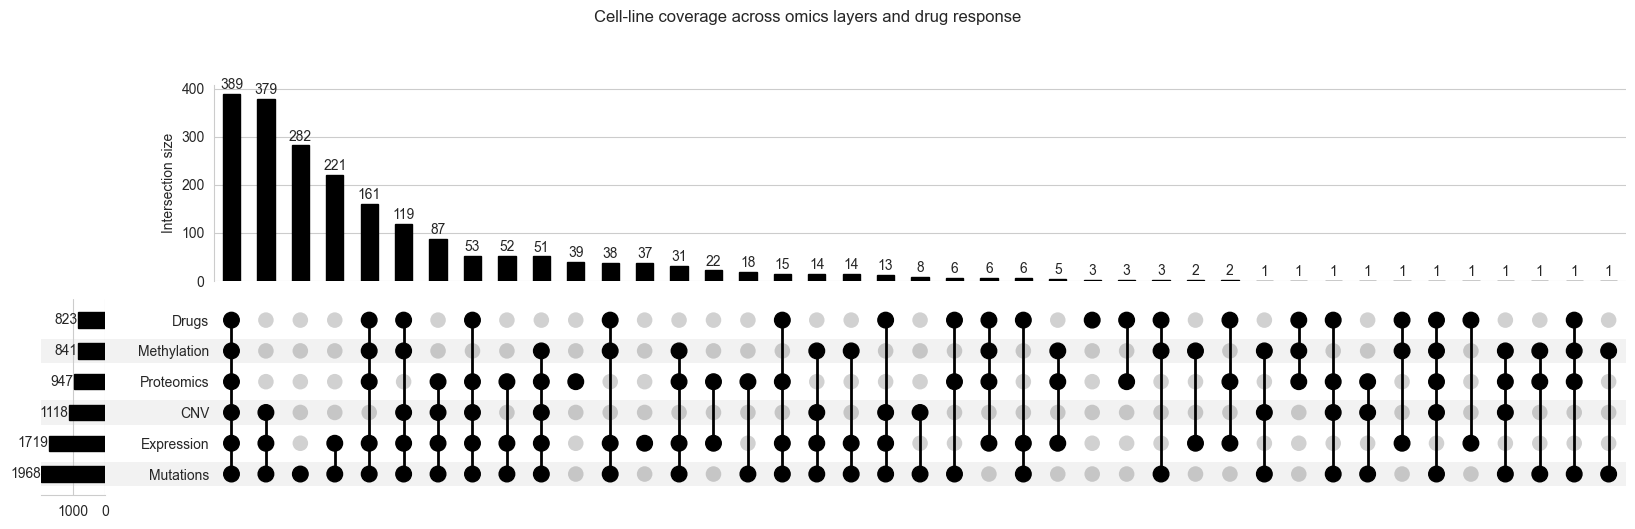

In [33]:
# Optional: UpSet plot if upsetplot is installed
try:
    from upsetplot import UpSet, from_contents
    contents = {
        "Expression": expr_ids,
        "Mutations":  mut_ids,
        "CNV":        cnv_ids,
        "Methylation": meth_ids,
        "Proteomics": prot_ids,
        "Drugs":      drug_ids,
    }
    upset_data = from_contents(contents)
    fig = plt.figure(figsize=(12, 5))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality").plot(fig=fig)
    plt.suptitle("Cell-line coverage across omics layers and drug response", y=1.02)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install upsetplot for richer visualization: %pip install upsetplot")
    # Fallback bar chart
    sizes = pd.Series({
        "Expression": len(expr_ids),
        "Mutations": len(mut_ids),
        "CNV": len(cnv_ids),
        "Methylation": len(meth_ids),
        "Proteomics": len(prot_ids),
        "Drugs": len(drug_ids),
        "ALL 5 + drugs": len(intersection_all),
    }).sort_values()
    sizes.plot(kind="barh", figsize=(8, 4), color="steelblue")
    plt.title("Cell-line coverage")
    plt.xlabel("# cell lines")
    plt.tight_layout()
    plt.show()

**Primary set** = the intersection of all 5 omics layers + drug response data.

In [ ]:
PRIMARY_CELLS = sorted(intersection_no_prot_no_meth)
INCLUDE_PROTEOMICS = False
INCLUDE_METHYLATION = False
print(f"Using 3 omics (no proteomics, no methylation): {len(PRIMARY_CELLS)} cell lines")


# Save to file for downstream notebooks
pd.Series(PRIMARY_CELLS).to_csv(PROCESSED_DIR / "primary_cell_lines.csv",
                                 index=False, header=["ModelID"])
print(f"\nSaved: {PROCESSED_DIR / 'primary_cell_lines.csv'}")


## 5. Per-layer cleaning

We process each layer separately: we convert it to a wide format (cell × feature), filter out missing values, and normalize where necessary.

### 5.1 Expression — subset to primary cells

In [35]:
expr_clean = expr.loc[expr.index.isin(PRIMARY_CELLS)].copy()
print(f"Expression subset: {expr_clean.shape}")
print(f"  NaN fraction: {expr_clean.isna().mean().mean():.2%}")
# Drop genes with any NaN (RNA-seq is dense so usually 0)
expr_clean = expr_clean.dropna(axis=1, how="any")
print(f"  After dropping NaN columns: {expr_clean.shape}")

Expression subset: (389, 19216)
  NaN fraction: 0.00%
  After dropping NaN columns: (389, 19216)


### 5.2 Mutations — pivot to wide binary matrix

In [36]:
# Filter to non-silent coding mutations
# DepMap variant categories: Silent, Missense, Nonsense, Frame_Shift_Del, Frame_Shift_Ins, etc.
mut_subset = mut[mut[MODEL_COL].isin(PRIMARY_CELLS)].copy()
print(f"Mutations in primary cells: {len(mut_subset):,} rows")

# Identify silent variants column and filter
if EFFECT_COL and EFFECT_COL in mut_subset.columns:
    print(f"\n{EFFECT_COL} value counts:")
    print(mut_subset[EFFECT_COL].value_counts().head(15))
    # Keep only protein-affecting variants
    affecting = ["MISSENSE", "NONSENSE", "FRAME_SHIFT_DEL", "FRAME_SHIFT_INS",
                 "IN_FRAME_DEL", "IN_FRAME_INS", "SPLICE_SITE", "NONSTOP",
                 "Missense_Mutation", "Nonsense_Mutation",
                 "Frame_Shift_Del", "Frame_Shift_Ins", "Splice_Site"]
    mut_subset = mut_subset[mut_subset[EFFECT_COL].isin(affecting)]
    print(f"\nAfter filtering to protein-affecting: {len(mut_subset):,} rows")

# Pivot to binary matrix
mut_wide = (mut_subset
            .groupby([MODEL_COL, GENE_COL])
            .size()
            .unstack(fill_value=0)
            .clip(upper=1)
            .astype(np.int8))
# Add missing cell lines as all-zero rows
missing_cells = set(PRIMARY_CELLS) - set(mut_wide.index)
if missing_cells:
    zeros = pd.DataFrame(0, index=list(missing_cells), columns=mut_wide.columns, dtype=np.int8)
    mut_wide = pd.concat([mut_wide, zeros])
mut_wide = mut_wide.loc[PRIMARY_CELLS]
print(f"\nBinary mutation matrix: {mut_wide.shape}")
print(f"Mean mutation rate per gene: {mut_wide.mean().mean():.3%}")

Mutations in primary cells: 413,331 rows

Variant_Classification value counts:
Variant_Classification
Missense_Mutation         335346
Frame_Shift_Del            27509
Nonsense_Mutation          22899
Splice_Site                12955
Frame_Shift_Ins            10367
In_Frame_Del                2192
Translation_Start_Site       742
In_Frame_Ins                 695
Nonstop_Mutation             480
5'Flank                      120
Splice_Region                 20
5'UTR                          3
3'Flank                        2
Intron                         1
Name: count, dtype: int64

After filtering to protein-affecting: 409,076 rows

Binary mutation matrix: (389, 19113)
Mean mutation rate per gene: 2.761%


### 5.3 CNV — subset

In [37]:
cnv_clean = cnv.select_dtypes(include=[np.number]).loc[cnv.index.isin(PRIMARY_CELLS)].copy()
# Add missing cells as rows of NaN, then fill with median (rare since CNV is dense)
missing = set(PRIMARY_CELLS) - set(cnv_clean.index)
if missing:
    nan_rows = pd.DataFrame(np.nan, index=list(missing), columns=cnv_clean.columns)
    cnv_clean = pd.concat([cnv_clean, nan_rows])
cnv_clean = cnv_clean.loc[PRIMARY_CELLS]
print(f"CNV subset: {cnv_clean.shape}, NaN fraction: {cnv_clean.isna().mean().mean():.2%}")
# Drop columns with > 5% NaN, fill rest with column median
high_missing = cnv_clean.isna().mean() > 0.05
cnv_clean = cnv_clean.loc[:, ~high_missing]
cnv_clean = cnv_clean.fillna(cnv_clean.median(numeric_only=True))
print(f"After cleaning: {cnv_clean.shape}")

CNV subset: (389, 19956), NaN fraction: 4.06%
After cleaning: (389, 19145)


### 5.4 Methylation — reshape and convert beta → M values

Beta values ​​∈ [0, 1] are ill-suited for linear models (due to heteroscedasticity near the boundaries). Standard practice is to use M = log2(β / (1 − β)).

In [39]:
def beta_to_m(beta):
    """Convert beta-values to M-values: log2(beta / (1 - beta))."""
    beta = np.asarray(beta, dtype=float)
    beta = np.clip(beta, 1e-6, 1 - 1e-6)  # avoid log(0) at boundaries
    return np.log2(beta / (1 - beta))


# Reshape methylation: rows=CpG clusters, cols=cell lines → cells × CpG
meta_cols_in_file = [c for c in ["locus_id", "CpG_sites_hg19", "avg_coverage"] 
                     if c in meth_raw.columns]
cell_cols = [c for c in meth_raw.columns if c not in meta_cols_in_file]

# Drop trailing junk row (locus_id == "NA_NA")
meth_raw = meth_raw[meth_raw["locus_id"].notna() & (meth_raw["locus_id"] != "NA_NA")]

# Map column names: "DMS53_LUNG" → "DMS53" → ACH-000XXX
meth_col_to_model = {c: to_model_id(c.split("_")[0], alias_map) for c in cell_cols}
meth_col_to_model = {k: v for k, v in meth_col_to_model.items() if v in PRIMARY_CELLS}
print(f"Methylation columns mappable to primary cells: {len(meth_col_to_model)}")

meth_subset = meth_raw[list(meth_col_to_model.keys())].copy()
meth_subset.columns = [meth_col_to_model[c] for c in meth_subset.columns]

# Use locus_id as feature name
feat_names = meth_raw["locus_id"].astype(str)
meth_subset.index = feat_names

meth_wide = meth_subset.T
print(f"Methylation wide: {meth_wide.shape}")

# Convert strings to numeric — 'NA' strings become real NaN
meth_m = meth_wide.apply(pd.to_numeric, errors="coerce")
print(f"After to_numeric NaN fraction: {meth_m.isna().mean().mean():.2%}")

# Drop columns that are entirely NaN after coercion
fully_nan = meth_m.isna().all(axis=0)
if fully_nan.any():
    print(f"Dropped {fully_nan.sum()} all-NaN columns")
    meth_m = meth_m.loc[:, ~fully_nan]

# Beta → M-value transformation
meth_m = pd.DataFrame(
    beta_to_m(meth_m.values),
    index=meth_m.index,
    columns=meth_m.columns
)
print(f"M-values: range [{np.nanmin(meth_m.values):.2f}, {np.nanmax(meth_m.values):.2f}]")

# Drop CpG features with >20% missing
missing_per_feat = meth_m.isna().mean(axis=0)
meth_m = meth_m.loc[:, missing_per_feat < 0.20]

# Impute remaining missing values with column median, then mean for fully missing cells
meth_m = meth_m.fillna(meth_m.median())
meth_m = meth_m.reindex(PRIMARY_CELLS)
meth_m = meth_m.fillna(meth_m.mean())
print(f"After cleaning: {meth_m.shape}")

Methylation columns mappable to primary cells: 389
Methylation wide: (389, 21337)
After to_numeric NaN fraction: 5.62%
M-values: range [-19.93, 19.93]
After cleaning: (389, 20071)


### 5.5 Proteomics 

In [40]:
if INCLUDE_PROTEOMICS:
    # Proteomics index may already be ModelID, or may need mapping
    prot_clean = prot.copy()
    # If index is not ModelID, try to map
    sample = prot_clean.index[0] if len(prot_clean) else None
    if sample and not str(sample).startswith("ACH-"):
        new_index = [to_model_id(s, alias_map) for s in prot_clean.index]
        prot_clean.index = new_index
        prot_clean = prot_clean[prot_clean.index.notna()]
        prot_clean = prot_clean[~prot_clean.index.duplicated(keep="first")]
    prot_clean = prot_clean.loc[prot_clean.index.isin(PRIMARY_CELLS)]
    # Add missing cells
    missing = set(PRIMARY_CELLS) - set(prot_clean.index)
    if missing:
        nan_rows = pd.DataFrame(np.nan, index=list(missing), columns=prot_clean.columns)
        prot_clean = pd.concat([prot_clean, nan_rows])
    prot_clean = prot_clean.loc[PRIMARY_CELLS]
    # Drop proteins with > 30% missing (DIA proteomics has structural missingness)
    high_missing = prot_clean.isna().mean() > 0.30
    prot_clean = prot_clean.loc[:, ~high_missing]
    # Fill rest with column median
    prot_clean = prot_clean.fillna(prot_clean.median())
    print(f"Proteomics clean: {prot_clean.shape}")
else:
    prot_clean = None
    print("Proteomics excluded — secondary set used.")

Proteomics clean: (389, 4167)


## 6. Feature engineering

We perform dimensionality reduction: for each layer, we retain the top-K most variable features and potentially predictive features for downstream drug-response modeling. This is a **must-have** in the *p ≫ n* regime; otherwise, models will overfit to noise. 

Following this filtering step, we apply z-score standardization **independently to each layer** (per-feature mean = 0, std = 1).

In [ ]:
from sklearn.preprocessing import StandardScaler

def top_variable_features(df: pd.DataFrame, top_k: int) -> pd.DataFrame:
    """Keep top-K features by variance (numeric columns only)."""
    numeric = df.select_dtypes(include=[np.number])
    variances = numeric.var(axis=0).sort_values(ascending=False)
    top_features = variances.head(top_k).index
    return numeric[top_features]

# Feature budgets — adjust per layer based on dataset size and typical practice
FEATURE_BUDGETS = {
    "expression":  5000,
    "mutations":   1000,   # already binary, take top by frequency rather than variance
    "cnv":         5000,
    "methylation": 5000,
    "proteomics":  3000,
}

# For mutations, "top variable" = most frequently mutated (across cells)
mut_freq = mut_wide.sum(axis=0).sort_values(ascending=False)
mut_top = mut_wide[mut_freq.head(FEATURE_BUDGETS["mutations"]).index]

expr_top = top_variable_features(expr_clean, FEATURE_BUDGETS["expression"])
cnv_top = top_variable_features(cnv_clean, FEATURE_BUDGETS["cnv"])
meth_top = top_variable_features(meth_m, FEATURE_BUDGETS["methylation"]) if INCLUDE_METHYLATION else None
prot_top = top_variable_features(prot_clean, FEATURE_BUDGETS["proteomics"]) if INCLUDE_PROTEOMICS else None

print("Filtered feature counts:")
print(f"  expression:   {expr_top.shape[1]:>5}")
print(f"  mutations:    {mut_top.shape[1]:>5}  (binary, top by frequency)")
print(f"  cnv:          {cnv_top.shape[1]:>5}")
if INCLUDE_METHYLATION:
    print(f"  methylation:  {meth_top.shape[1]:>5}")
if INCLUDE_PROTEOMICS:
    print(f"  proteomics:   {prot_top.shape[1]:>5}")


In [ ]:
# Standardize each layer (z-score). Mutations stay binary.
def standardize(df: pd.DataFrame) -> pd.DataFrame:
    scaler = StandardScaler()
    arr = scaler.fit_transform(df.values)
    return pd.DataFrame(arr, index=df.index, columns=df.columns)

expr_std = standardize(expr_top)
cnv_std = standardize(cnv_top)
meth_std = standardize(meth_top) if INCLUDE_METHYLATION else None
prot_std = standardize(prot_top) if INCLUDE_PROTEOMICS else None
# Mutations remain binary


## B. EDA

## 1. Dataset overview table

In [50]:
def layer_summary(name, df):
    return {
        "Layer": name,
        "Samples": df.shape[0],
        "Features": df.shape[1],
        "Missing (%)": round(
            100 * df.isna().sum().sum() / (df.shape[0] * df.shape[1]),
            2
        )
    }

overview_rows = [
    layer_summary("Expression", expr_std),
    layer_summary("Mutations", mut_top),
    layer_summary("CNV", cnv_std),
    layer_summary("Methylation", meth_std),
]

if INCLUDE_PROTEOMICS:
    overview_rows.append(
        layer_summary("Proteomics", prot_std)
    )

overview_df = pd.DataFrame(overview_rows)

display(overview_df)

,Layer,Samples,Features,Missing (%)
0,Expression,389,5000,0.0
1,Mutations,389,1000,0.0
2,CNV,389,5000,0.0
3,Methylation,389,5000,0.0
4,Proteomics,389,3000,0.0


In [51]:
print("CTRPv2 Overview")
print("-" * 50)

print(f"Unique cell lines : {df_ctrp['cell_line_uid'].nunique():,}")
print(f"Unique compounds  : {df_ctrp['compound_id'].nunique():,}")
print(f"Total experiments : {len(df_ctrp):,}")

print("\nDrug response missingness:")
for metric in ["AAC", "IC50", "EC50", "HS", "Einf"]:
    missing_pct = 100 * df_ctrp[metric].isna().mean()
    print(f"  {metric:<5}: {missing_pct:.2f}%")

CTRPv2 Overview
--------------------------------------------------
Unique cell lines : 887
Unique compounds  : 544
Total experiments : 395,263

Drug response missingness:
  AAC  : 6.12%
  IC50 : 37.95%
  EC50 : 6.12%
  HS   : 6.12%
  Einf : 6.12%


## 2. UMAP per layer
UMAP of each layer individually, colored by `OncotreeLineage`. The goal is to see how well each omics layer captures the tissue-of-origin structure.

In [44]:
import umap

# Build a lineage lookup for the primary cell lines
lineage = (model_meta.set_index("ModelID")["OncotreeLineage"]
           .reindex(PRIMARY_CELLS)
           .fillna("Unknown"))

# Reduce to top 15 lineages for plotting clarity
top_lineages = lineage.value_counts().head(15).index
lineage_plot = lineage.where(lineage.isin(top_lineages), "Other")

def umap_layer(X: pd.DataFrame, n_neighbors: int = 15) -> np.ndarray:
    """Run UMAP on a layer, return 2D embedding."""
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.3,
                        random_state=RANDOM_STATE, n_components=2)
    return reducer.fit_transform(X.values)

# Run UMAP per layer
embeddings = {
    "Expression":  umap_layer(expr_std),
    "Mutations":   umap_layer(mut_top.astype(float)),
    "CNV":         umap_layer(cnv_std),
    "Methylation": umap_layer(meth_std),
}
if INCLUDE_PROTEOMICS:
    embeddings["Proteomics"] = umap_layer(prot_std)

In [46]:
for name, df in [("expr_std", expr_std), ("mut_top", mut_top),
                 ("cnv_std", cnv_std), ("meth_std", meth_std)]:
    dup = df.index.duplicated().sum()
    print(f"{name:<12} shape={df.shape}, duplicates={dup}")
if INCLUDE_PROTEOMICS:
    dup = prot_std.index.duplicated().sum()
    print(f"prot_std     shape={prot_std.shape}, duplicates={dup}")

expr_std     shape=(389, 5000), duplicates=0
mut_top      shape=(389, 1000), duplicates=0
cnv_std      shape=(389, 5000), duplicates=0
meth_std     shape=(389, 5000), duplicates=0
prot_std     shape=(389, 3000), duplicates=0


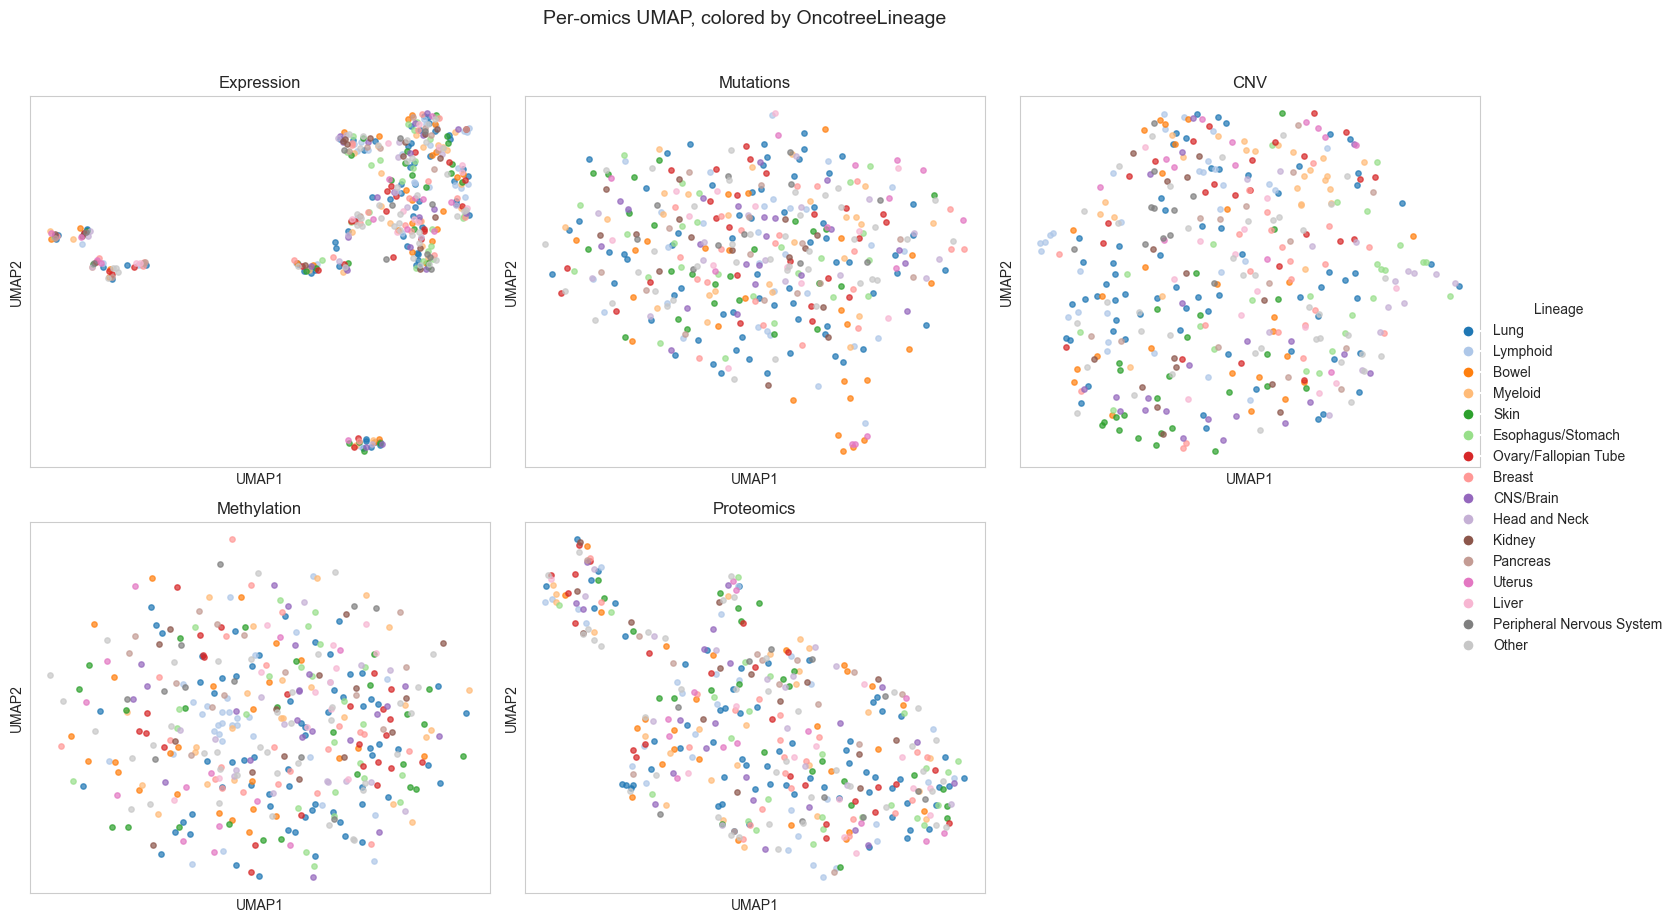

In [47]:
# Plot UMAPs side by side
n_layers = len(embeddings)
n_cols = 3
n_rows = (n_layers + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.flatten() if n_layers > 1 else [axes]

palette = sns.color_palette("tab20", n_colors=len(top_lineages) + 1)
color_map = dict(zip(list(top_lineages) + ["Other"], palette))

for ax, (name, emb) in zip(axes, embeddings.items()):
    for lin in list(top_lineages) + ["Other"]:
        mask = (lineage_plot == lin).values
        ax.scatter(emb[mask, 0], emb[mask, 1], s=15, alpha=0.7,
                   color=color_map[lin], label=lin if name == "Expression" else None)
    ax.set_title(name)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[len(embeddings):]:
    ax.axis("off")

# Legend on the figure
handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=color_map[l], markersize=8, label=l)
           for l in list(top_lineages) + ["Other"]]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.12, 0.5),
           title="Lineage", frameon=False)
plt.suptitle("Per-omics UMAP, colored by OncotreeLineage", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Conclusion**: we need to do a batch correction for expression, methylation and proteomics data

## 3. Cross-omics PC correlation

We calculate the top 10 principal components for each layer, followed by the correlation matrix between the PCs of different layers. A high correlation between the PC1 of the expression layer and the PC1 of the proteomics layer is expected. Low correlation between mutations and the other layers is also expected (as mutation data is binary and sparse).

Concatenated PC matrix: (389, 50)


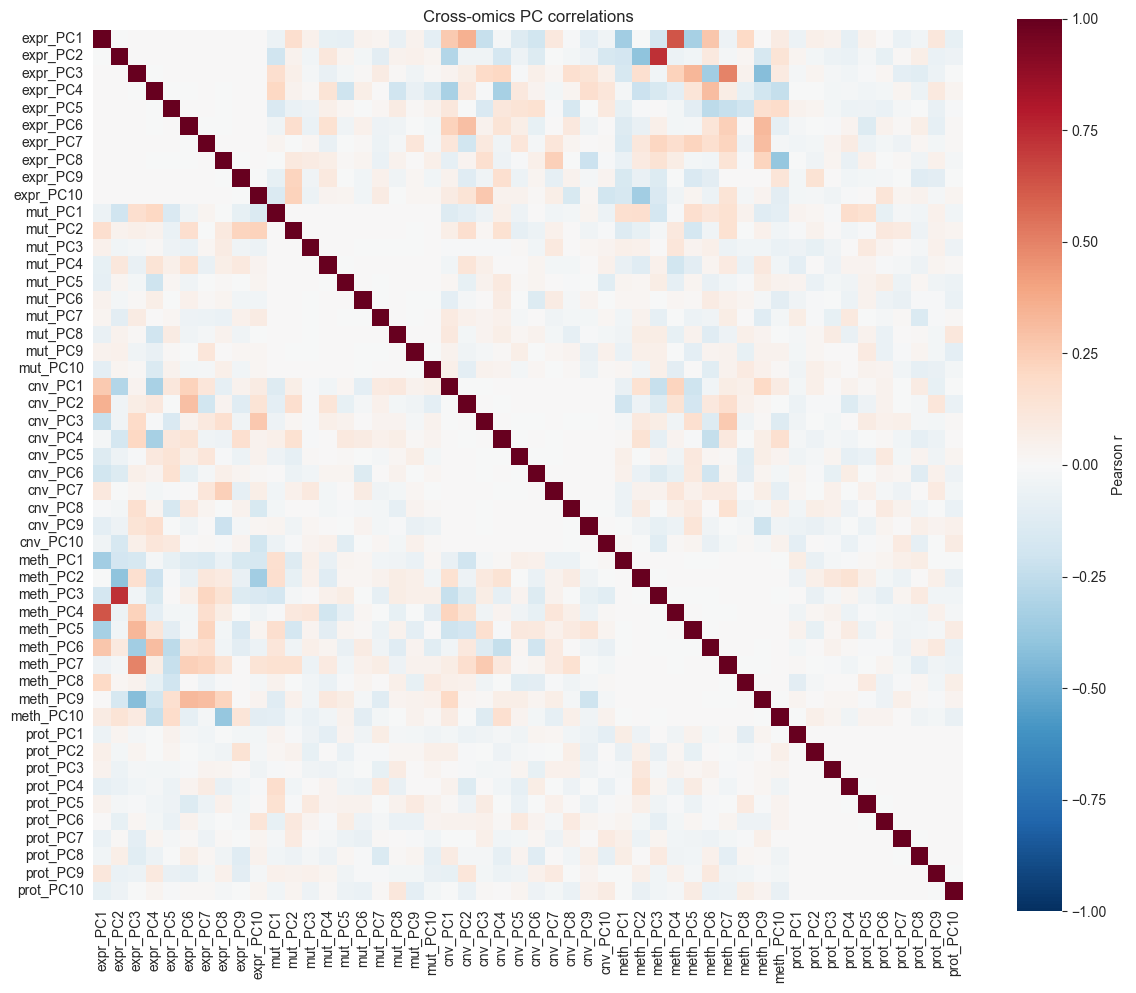

In [81]:
from sklearn.decomposition import PCA

def top_pcs(X: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    pca = PCA(n_components=n, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(X.values)
    return pd.DataFrame(pcs, index=X.index,
                        columns=[f"PC{i+1}" for i in range(n)])

layers_for_pca = {
    "expr":  expr_std,
    "mut":   mut_top.astype(float),
    "cnv":   cnv_std,
    "meth":  meth_std,
}
if INCLUDE_PROTEOMICS:
    layers_for_pca["prot"] = prot_std

pcs_per_layer = {name: top_pcs(X, n=10) for name, X in layers_for_pca.items()}

# Build a single dataframe with all PCs
all_pcs = pd.concat({k: v for k, v in pcs_per_layer.items()}, axis=1)
all_pcs.columns = [f"{layer}_{pc}" for layer, pc in all_pcs.columns]
print(f"Concatenated PC matrix: {all_pcs.shape}")

# Correlation heatmap
corr = all_pcs.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson r"})
plt.title("Cross-omics PC correlations")
plt.tight_layout()
plt.show()

**Conclusion**: The omics layers are largely independent, which justifies their combined use in a multi-omics model. The strongest signal is between expression and methylation, consistent with transcriptional silencing. Expression and proteomics show weaker correlation than expected, likely due to missing data imputation flattening the proteomics signal. Mutations are uncorrelated with all other layers, as expected given their binary, sparse nature.

## 4. Drug response landscape

In [56]:
# Map drug response cell lines to ModelID, subset to primary cells
drugs["ModelID"] = drugs["cell_line"].apply(lambda x: to_model_id(x, alias_map))
drugs_primary = drugs[drugs["ModelID"].isin(PRIMARY_CELLS)].copy()
print(f"Drug response in primary cells: {len(drugs_primary):,} rows")
print(f"Unique compounds: {drugs_primary['compound'].nunique()}")
print(f"Mean AAC: {drugs_primary['AAC'].mean():.3f}")

Drug response in primary cells: 173,519 rows
Unique compounds: 544
Mean AAC: 0.151


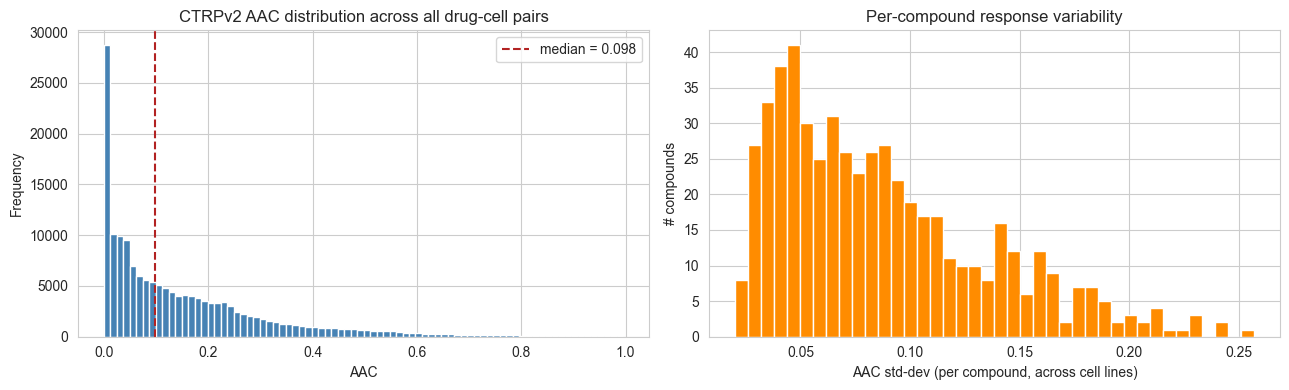

In [57]:
# AAC distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall histogram
axes[0].hist(drugs_primary["AAC"].dropna(), bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("AAC")
axes[0].set_ylabel("Frequency")
axes[0].set_title("CTRPv2 AAC distribution across all drug-cell pairs")
axes[0].axvline(drugs_primary["AAC"].median(), color="firebrick", linestyle="--",
                label=f"median = {drugs_primary['AAC'].median():.3f}")
axes[0].legend()

# Per-drug variance
drug_var = drugs_primary.groupby("compound")["AAC"].std().sort_values(ascending=False)
axes[1].hist(drug_var.dropna(), bins=40, color="darkorange", edgecolor="white")
axes[1].set_xlabel("AAC std-dev (per compound, across cell lines)")
axes[1].set_ylabel("# compounds")
axes[1].set_title("Per-compound response variability")
plt.tight_layout()
plt.show()

**Conclusion:** 
AAC distribution is heavily right-skewed with a median of 0.098, indicating that most drug-cell pairs show little to no response — which is expected in a large-scale screen. Per-compound variability is moderate (std mostly between 0.03–0.15), meaning most drugs do show some differential response across cell lines, which is a prerequisite for meaningful drug response prediction.

### Drug response matrix (cells × compounds)

For the model, we will need a pivot table: rows = cell lines, columns = compounds, values ​​= AAC.

Drug matrix shape: (389, 544)
  Sparsity (NaN fraction): 24.7%


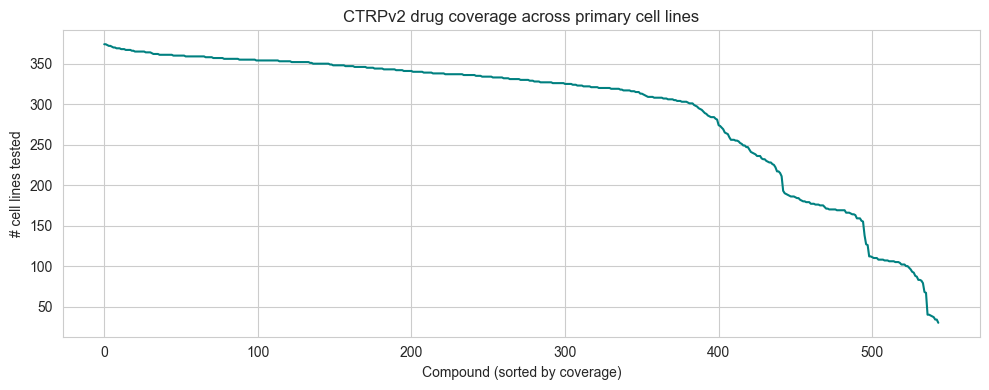


Min coverage: 30, Max: 374, Median: 330


In [58]:
drug_matrix = (drugs_primary
               .groupby(["ModelID", "compound"])["AAC"]
               .mean()
               .unstack())
print(f"Drug matrix shape: {drug_matrix.shape}")
print(f"  Sparsity (NaN fraction): {drug_matrix.isna().mean().mean():.1%}")

# Drug coverage: how many cells each drug was tested in
drug_coverage = drug_matrix.notna().sum(axis=0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
drug_coverage.reset_index(drop=True).plot(ax=ax, color="teal")
ax.set_xlabel("Compound (sorted by coverage)")
ax.set_ylabel("# cell lines tested")
ax.set_title("CTRPv2 drug coverage across primary cell lines")
plt.tight_layout()
plt.show()
print(f"\nMin coverage: {drug_coverage.min()}, Max: {drug_coverage.max()}, Median: {drug_coverage.median():.0f}")

**Conclusion:** Most compounds were tested across the majority of primary cell lines (median coverage: 330 out of 389), with a sharp drop-off for the last ~100 compounds. Overall sparsity is 24.7%, which is manageable and consistent with a large-scale screening dataset where not all drug-cell combinations are measured.

## Save processed matrices

In [ ]:
# Save all processed matrices to parquet
to_save = {
    "expression":  expr_std,
    "mutations":   mut_top,
    "cnv":         cnv_std,
    "drug_response": drug_matrix,
}
if INCLUDE_METHYLATION:
    to_save["methylation"] = meth_std
if INCLUDE_PROTEOMICS:
    to_save["proteomics"] = prot_std

for name, df in to_save.items():
    out = PROCESSED_DIR / f"{name}.parquet"
    # Reset index to a column for parquet roundtrip
    df.reset_index().rename(columns={"index": "ModelID"}).to_parquet(out, index=False)
    print(f"  Saved: {out.name:<25} {df.shape}")

# Also save metadata
model_meta.loc[model_meta["ModelID"].isin(PRIMARY_CELLS)].to_parquet(
    PROCESSED_DIR / "cell_metadata.parquet", index=False
)
print(f"  Saved: cell_metadata.parquet")

print(f"\nAll processed files in: {PROCESSED_DIR.resolve()}")
for p in sorted(PROCESSED_DIR.glob("*.parquet")):
    size_mb = p.stat().st_size / 1024**2
    print(f"  {p.name:<35} {size_mb:>7.2f} MB")
